# Diabatic monomer stack — prediction diagnostics

Plots for the Phase-1 frozen monomer stack (`checkpoints/monomer_h2o_h3o_oh`):

1. **Correlation** of predicted vs reference energy, dipole, and polarizability on the held-out set.
2. **Atomic energy surfaces** `E(q, spin)` for H and O — the EEM parabola the model carries per element, with the isolated-atom QC anchors overlaid.
3. **O–H elongation scans** for H2O, H3O⁺, OH⁻ — atomic charges and channel compliances as one O–H bond is stretched.

Figures are also written to `notebooks/figures/`.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # macOS libomp
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

import numpy as np
import torch
import matplotlib.pyplot as plt
import ase.units
from ase.data import atomic_numbers as ATOMIC_NUMBER, chemical_symbols

from rsfff.mlip import DiabaticStateLibrary, build_monomer_model, AtomicStateReference
from rsfff.mlip.diabats import assign_from_headers
from rsfff.train.config import load_config
from rsfff.train.data import Batch, load_datasets, load_reference_energies, split_indices

torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

FIGDIR = "notebooks/figures"
os.makedirs(FIGDIR, exist_ok=True)
DEBYE = 4.803204            # e*Angstrom -> Debye
HA2KCAL = 627.5094740631    # Hartree -> kcal/mol
BOHR = ase.units.Bohr       # Angstrom per bohr
# The model works in e^2*Angstrom^2/Ha; the QC references are a0^3 (bohr^3), and
# rsfff.train.data converts them a0^3 -> e^2*Ang^2/Ha via *Bohr^2 on load (a0^3 = e^2 a0^2/Ha).
# Dividing by Bohr^2 takes any polarizability in this notebook back to bohr^3.
POL_TO_BOHR3 = 1.0 / BOHR**2
SPECIES = ["h2o", "h3o+", "oh-"]
COLOR = {"h2o": "#2166ac", "h3o+": "#b2182b", "oh-": "#1b7837"}

In [2]:
CFG = load_config("configs/monomer_h2o_h3o_oh.yaml")
LIB = DiabaticStateLibrary.from_yaml(CFG.data.diabatic_states)
DATASET = load_datasets(CFG.data.path, dtype=torch.float64, library=LIB)
TYPES = DATASET.unique_atomic_numbers
E0 = load_reference_energies(CFG.data.reference_energies, TYPES)
STATES = AtomicStateReference.from_json(CFG.data.atomic_reference_states, TYPES)

MODEL = build_monomer_model(CFG.features, CFG.monomer, CFG.sqe, TYPES, E0, STATES)
ckpt = torch.load("checkpoints/monomer_h2o_h3o_oh/best.pt", map_location="cpu", weights_only=False)
MODEL.load_state_dict(ckpt["model_state"])
MODEL.eval()
print(f"loaded epoch {ckpt['epoch'] + 1}, val loss {ckpt['val_loss']:.3e};  species Z={TYPES}")


def build_batch(symbols, positions, config_type):
    """One-frame Batch with the diabatic assignment resolved from the state library."""
    a = assign_from_headers(LIB, symbols, config_type=config_type)
    n = len(symbols)
    return Batch(
        positions=torch.tensor(np.asarray(positions, dtype=float)),
        atomic_numbers=torch.tensor([ATOMIC_NUMBER[s] for s in symbols], dtype=torch.long),
        batch_idx=torch.zeros(n, dtype=torch.long), n_systems=1,
        energy=torch.zeros(1), forces=torch.zeros(n, 3),
        total_charge=torch.tensor([float(a.fragment_charge[0])]),
        fragment_idx=torch.tensor(a.fragment_idx),
        fragment_charge=torch.tensor(a.fragment_charge),
        fragment_two_s=torch.tensor(a.fragment_two_s), n_fragments=1,
        bond_index=torch.tensor(a.bond_index),
        bond_batch=torch.zeros(a.bond_index.shape[1], dtype=torch.long),
    )

loaded epoch 195, val loss 8.143e-06;  species Z=[1, 8]


## 1. Correlation plots (held-out set)

Energy is shown in **kcal/mol relative to each species' lowest sampled configuration** — the
absolute energies of the three species differ by ~1 Ha, which would otherwise collapse each into
a single point and hide the actual predictive spread. (A rigid per-species offset is the
atomization-energy term the reference-state anchors trade off against; dynamics sees only this
relative surface.) Dipole is in Debye, polarizability in **bohr³ (a₀³)**, both component-wise.

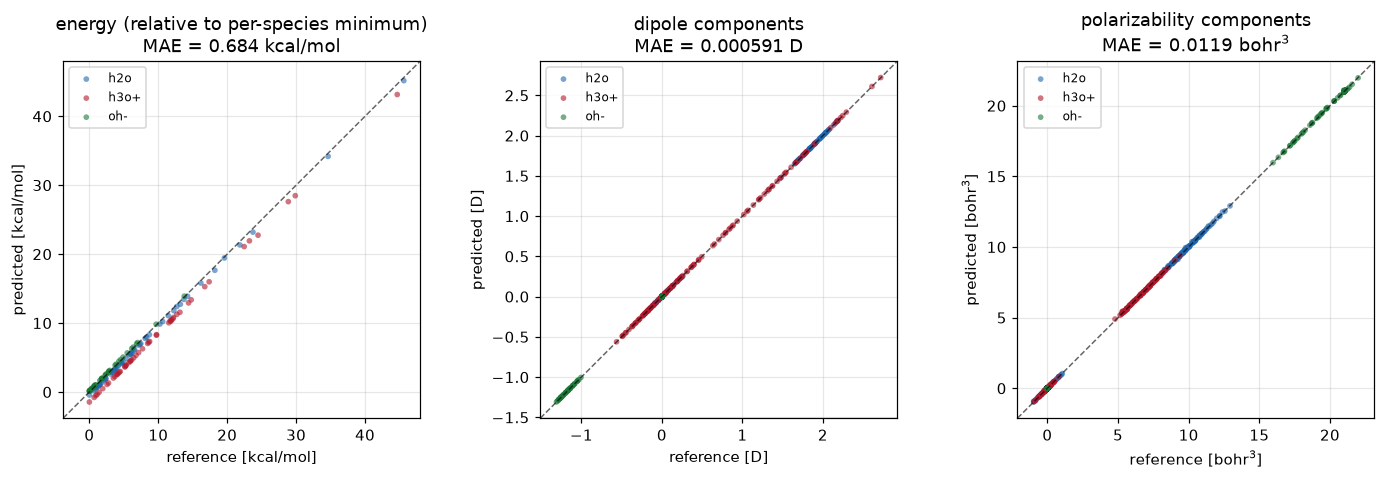

In [3]:
_, VAL = split_indices(len(DATASET), CFG.data.holdout_fraction, CFG.data.seed)
per_file = len(DATASET) // len(SPECIES)
species_of = lambda i: SPECIES[int(i) // per_file]

P = {s: {k: [] for k in ("E", "Eref", "mu", "muref", "a", "aref")} for s in SPECIES}
iu, ju = torch.triu_indices(3, 3)
for i in VAL.tolist():
    b = DATASET.flat_batch(torch.tensor([i]))
    with torch.no_grad():
        o = MODEL(b)
    s = species_of(i)
    P[s]["E"].append(float(o.energy));      P[s]["Eref"].append(float(b.energy))
    P[s]["mu"]  += (o.dipole[0] * DEBYE).tolist()
    P[s]["muref"] += (b.dipole[0] * DEBYE).tolist()
    P[s]["a"]  += (o.alpha[0][iu, ju] * POL_TO_BOHR3).tolist()       # -> bohr^3
    P[s]["aref"] += (b.polarizability[0][iu, ju] * POL_TO_BOHR3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

def scatter_panel(ax, key_p, key_r, title, unit, prep=None):
    allp, allr = [], []
    for s in SPECIES:
        p, r = np.array(P[s][key_p]), np.array(P[s][key_r])
        if prep is not None:        # per-species transform (e.g. energy -> kcal/mol from min)
            p, r = prep(p, r)
        ax.scatter(r, p, s=14, alpha=0.6, color=COLOR[s], label=s, edgecolors="none")
        allp += p.tolist(); allr += r.tolist()
    allp, allr = np.array(allp), np.array(allr)
    lo, hi = min(allr.min(), allp.min()), max(allr.max(), allp.max())
    pad = (hi - lo) * 0.05
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, alpha=0.6)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad); ax.set_aspect("equal")
    ax.set_title(f"{title}\nMAE = {np.abs(allp - allr).mean():.3g} {unit}")
    ax.set_xlabel(f"reference [{unit}]"); ax.set_ylabel(f"predicted [{unit}]")
    ax.legend(fontsize=8, loc="upper left")

# Energy: kcal/mol relative to each species' lowest sampled reference configuration.
relative_kcal = lambda p, r: ((p - r.min()) * HA2KCAL, (r - r.min()) * HA2KCAL)
scatter_panel(axes[0], "E", "Eref", "energy (relative to per-species minimum)",
              "kcal/mol", prep=relative_kcal)
scatter_panel(axes[1], "mu", "muref", "dipole components", "D")
scatter_panel(axes[2], "a", "aref", "polarizability components", r"bohr$^3$")
fig.tight_layout(); fig.savefig(f"{FIGDIR}/correlation.png", bbox_inches="tight"); plt.show()

## 2. Atomic energy surfaces `E(q, spin)`

A lone atom has an all-zero density and no channels, so the model's energy collapses to the
per-element EEM parabola `E = E0[Z] + E_1(e) + \chi q + \tfrac12 \eta q^2`, where the embedding
`e` — and hence `\chi`, `\eta` — depends on the fragment charge *and* its spin `2S`. Sweeping both
therefore traces the parabola and its (modest) spin dependence directly out of the trained model.

Stars are the isolated-atom QC anchors the model was trained against; the red ✗ is H⁻, which is
unbound at b3lyp/def2-svpd and excluded from the loss.

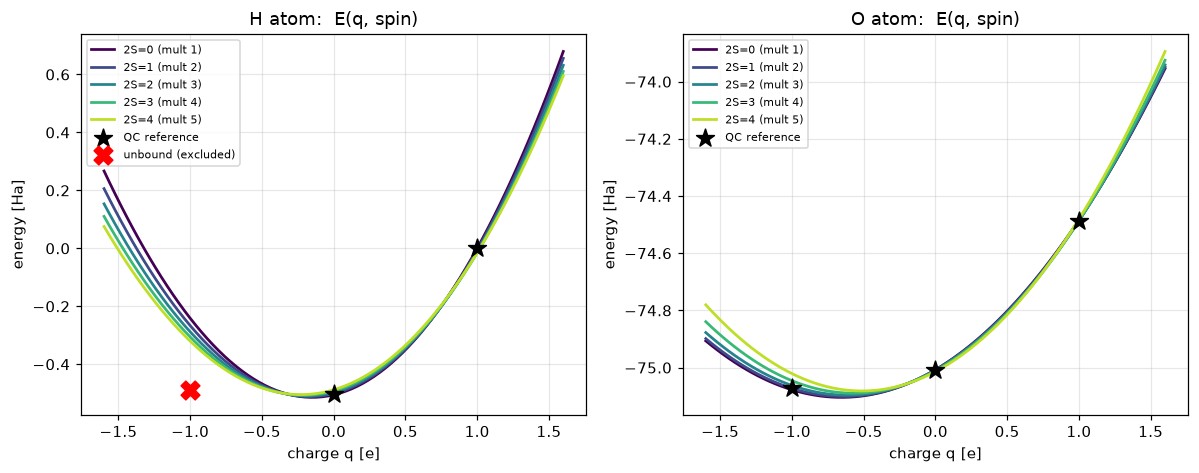

In [4]:
def build_atom(Z, q, two_s):
    return Batch(
        positions=torch.zeros(1, 3), atomic_numbers=torch.tensor([Z]),
        batch_idx=torch.zeros(1, dtype=torch.long), n_systems=1,
        energy=torch.zeros(1), forces=torch.zeros(1, 3),
        total_charge=torch.tensor([float(q)]),
        fragment_idx=torch.zeros(1, dtype=torch.long),
        fragment_charge=torch.tensor([float(q)]),
        fragment_two_s=torch.tensor([float(two_s)]), n_fragments=1,
        bond_index=torch.zeros(2, 0, dtype=torch.long),
        bond_batch=torch.zeros(0, dtype=torch.long),
    )

charges = np.linspace(-1.6, 1.6, 81)
two_s_values = range(5)
spin_colors = plt.cm.viridis(np.linspace(0, 0.9, len(list(two_s_values))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (Z, sym) in zip(axes, [(1, "H"), (8, "O")]):
    for two_s in two_s_values:
        with torch.no_grad():
            E = [float(MODEL(build_atom(Z, q, two_s)).energy) for q in charges]
        ax.plot(charges, E, color=spin_colors[two_s], lw=1.8,
                label=f"2S={two_s} (mult {two_s + 1})")
    for k, label in enumerate(STATES.symbols):
        if chemical_symbols[int(TYPES[int(STATES.species_idx[k])])] != sym:
            continue
        bound = bool(STATES.bound[k])
        ax.scatter([float(STATES.charge[k])], [float(STATES.energy[k])],
                   marker="*" if bound else "X", s=150,
                   color="k" if bound else "red", zorder=5,
                   label=("QC reference" if bound else "unbound (excluded)"))
    ax.set_title(f"{sym} atom:  E(q, spin)")
    ax.set_xlabel("charge q [e]"); ax.set_ylabel("energy [Ha]")
    handles, labels = ax.get_legend_handles_labels()
    seen = dict(zip(labels, handles))            # dedupe repeated reference labels
    ax.legend(seen.values(), seen.keys(), fontsize=7.5)
fig.tight_layout(); fig.savefig(f"{FIGDIR}/atom_energy.png", bbox_inches="tight"); plt.show()

## 3. O–H elongation scans

Starting from each equilibrium geometry, one O–H bond (O0–H1) is stretched while everything else
is held fixed. Top row: the SQE charge on every atom. Bottom row: the learned compliance of every
channel (dashed = the stretched bond).

**Caveat:** the training data is Wigner-sampled near equilibrium (shaded band, roughly
0.85–1.15 Å). Beyond it the curves are *extrapolation* — the model has no dissociation data yet,
which is what Phase 3 adds. The point here is the qualitative response: within-fragment compliance
rises then falls as the bond stretches, and the stretched channel separates clearly from the
spectator channels.

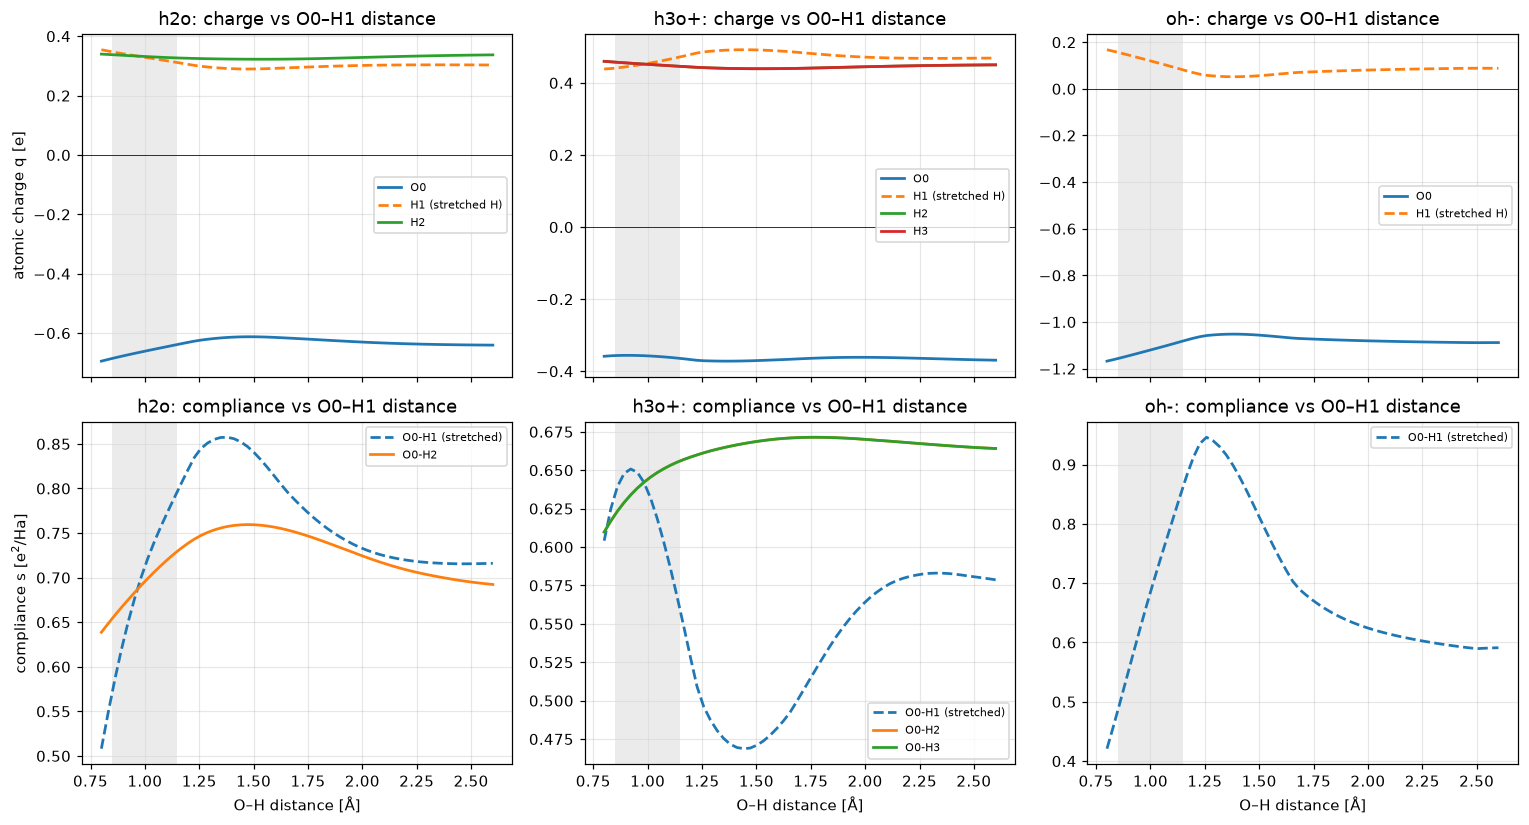

In [5]:
GEOMETRY = {
    "h2o":  (["O", "H", "H"],
             [[0, 0, 0.1178], [0, 0.7642, -0.4712], [0, -0.7642, -0.4714]]),
    "h3o+": (["O", "H", "H", "H"],
             [[0, 0, 0.0749], [0, 0.9436, -0.1997], [0.8172, -0.4718, -0.1997],
              [-0.8172, -0.4718, -0.1997]]),
    "oh-":  (["O", "H"], [[0, 0, 0.1078], [0, 0, -0.8621]]),
}
distances = np.linspace(0.80, 2.60, 60)

fig, axes = plt.subplots(2, 3, figsize=(14, 7.6), sharex=True)
for col, s in enumerate(SPECIES):
    symbols, pos0 = GEOMETRY[s]
    pos0 = np.array(pos0, dtype=float)
    unit = (pos0[1] - pos0[0]) / np.linalg.norm(pos0[1] - pos0[0])   # O0 -> H1
    r0 = float(np.linalg.norm(pos0[1] - pos0[0]))

    q_trace = {i: [] for i in range(len(symbols))}
    s_trace = None
    ref_batch = build_batch(symbols, pos0, s)
    for r in distances:
        pos = pos0.copy(); pos[1] = pos0[0] + r * unit
        with torch.no_grad():
            o = MODEL(build_batch(symbols, pos, s))
        for i in range(len(symbols)):
            q_trace[i].append(float(o.charges[i]))
        if s_trace is None:
            s_trace = [[] for _ in range(ref_batch.bond_index.shape[1])]
        for e in range(len(s_trace)):
            s_trace[e].append(float(o.compliance[e]))

    ax_q, ax_s = axes[0, col], axes[1, col]
    for a in (ax_q, ax_s):
        a.axvspan(0.85, 1.15, color="0.85", alpha=0.5, lw=0)   # training band
    for i in range(len(symbols)):
        ax_q.plot(distances, q_trace[i], lw=1.8, ls="--" if i == 1 else "-",
                  label=f"{symbols[i]}{i}" + (" (stretched H)" if i == 1 else ""))
    ax_q.axhline(0, color="k", lw=0.5); ax_q.set_title(f"{s}: charge vs O0–H1 distance")
    ax_q.legend(fontsize=7.5)
    for e in range(len(s_trace)):
        a, bb = int(ref_batch.bond_index[0, e]), int(ref_batch.bond_index[1, e])
        stretched = (a == 0 and bb == 1)
        ax_s.plot(distances, s_trace[e], lw=1.8, ls="--" if stretched else "-",
                  label=f"{symbols[a]}{a}-{symbols[bb]}{bb}" + (" (stretched)" if stretched else ""))
    ax_s.set_title(f"{s}: compliance vs O0–H1 distance")
    ax_s.set_xlabel("O–H distance [Å]"); ax_s.legend(fontsize=7.5)

axes[0, 0].set_ylabel("atomic charge q [e]")
axes[1, 0].set_ylabel(r"compliance s [e$^2$/Ha]")
fig.tight_layout(); fig.savefig(f"{FIGDIR}/oh_scan.png", bbox_inches="tight"); plt.show()